In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2 as cv2

In [2]:
path_to_data = '/kaggle/input/mango-leaf-disease-detection-raw-augmented-data'

In [3]:
data = []
labels = []

img_size = (224, 224)
for folder in os.listdir(path_to_data):
    print(folder)
    for file in os.listdir(os.path.join(path_to_data, folder)):
        img_path = os.path.join(path_to_data, folder, file)
        img = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        data.append(img)
        labels.append(folder)

# Convert to NumPy arrays if needed
data = np.array(data, dtype=np.float32)
labels = np.array(labels)

gall_midge
anthracnose
die_black
powdery_mildew
healthy


In [4]:
# Normalization
data = data/255.0

In [ ]:
data[0]

In [5]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform labels
encoded_labels = label_encoder.fit_transform(labels)

# Create mapping of original labels to encoded values
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

# Print the mapping
print("Label Mapping:")
for original, encoded in label_mapping.items():
    print(f"{original} -> {encoded}")

# Print the transformed labels
print("\nEncoded Labels:")
print(encoded_labels)

Label Mapping:
anthracnose -> 0
die_black -> 1
gall_midge -> 2
healthy -> 3
powdery_mildew -> 4

Encoded Labels:
[2 2 2 ... 3 3 3]


In [6]:
np.unique(encoded_labels)

array([0, 1, 2, 3, 4])

In [ ]:
data[0]

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Define label mapping
label_mapping = {
    0: "Anthracnose",
    1: "Die Black",
    2: "Gall Midge",
    3: "Healthy",
    4: "Powdery Mildew"
}

# Sample 5 random indices from each class
r_b = random.sample(list(np.where(encoded_labels == 0)[0]), 5)
r_f = random.sample(list(np.where(encoded_labels == 1)[0]), 5)
r_g = random.sample(list(np.where(encoded_labels == 2)[0]), 5)
r_m = random.sample(list(np.where(encoded_labels == 3)[0]), 5)
r_se = random.sample(list(np.where(encoded_labels == 4)[0]), 5)

# Combine the selected indices and reshape into a 5x5 grid
plots = np.array(r_b + r_f + r_g + r_m + r_se).reshape(5, 5)

# Create subplots
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing

# Plot images with corresponding class names
for i in range(5):
    for j in range(5):
        idx = plots[i, j]
        ax[i, j].imshow(data[idx])  # RGB images, so no cmap='gray'
        ax[i, j].set_title(f"{label_mapping[encoded_labels[idx]]}", fontsize=8)
        ax[i, j].axis('off')

plt.show()


In [ ]:
# Flatten each color channel
red_values = data[:, :, :, 0].ravel()   # Red channel
green_values = data[:, :, :, 1].ravel() # Green channel
blue_values = data[:, :, :, 2].ravel()  # Blue channel

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(red_values, bins=256, color='red', alpha=0.6, label="Red Channel")
plt.hist(green_values, bins=256, color='green', alpha=0.6, label="Green Channel")
plt.hist(blue_values, bins=256, color='blue', alpha=0.6, label="Blue Channel")

# Labels and Title
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.title("RGB Histogram of All Images")
plt.legend()
plt.show()

In [ ]:
# Count occurrences of each label
unique_labels, label_counts = np.unique(encoded_labels, return_counts=True)

# Create a bar plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=unique_labels, y=label_counts, palette="viridis")

# Add count labels on top of each bar
for i, count in enumerate(label_counts):
    ax.text(i, count + 0.5, str(count), ha='center', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Distribution of Encoded Labels")
plt.show()

In [ ]:
encoded_labels

In [7]:
from sklearn.model_selection import train_test_split
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(data, encoded_labels, test_size=0.2, random_state=42, shuffle=True)

# Ensure correct shape for RGB images
X_train = X_train.reshape(-1, 224, 224, 3)
X_test = X_test.reshape(-1, 224, 224, 3)

# Define number of classes
num_classes = len(np.unique(encoded_labels))

print("Number of classes:", num_classes)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 5
X_train shape: (6984, 224, 224, 3)
X_test shape: (1746, 224, 224, 3)


In [8]:
print("Unique classes in y_train:", np.unique(y_train))
print("Unique classes in y_test:", np.unique(y_test))
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Unique classes in y_train: [0 1 2 3 4]
Unique classes in y_test: [0 1 2 3 4]
y_train shape: (6984,)
y_test shape: (1746,)


# DenseNet-201

In [9]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, AveragePooling2D, Add, Flatten,GlobalAveragePooling2D, Dense,ZeroPadding2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Conv2D, concatenate, AveragePooling2D, ZeroPadding2D, MaxPooling2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

def conv_block(x, growth_rate, name):
    """A building block for a dense block."""
    bn_axis = 3 if K.image_data_format() == 'channels_last' else 1
    x1 = BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name=name + '_0_bn')(x)
    x1 = Activation('relu', name=name + '_0_relu')(x1)
    x1 = Conv2D(4 * growth_rate, 1, use_bias=False, name=name + '_1_conv')(x1)
    x1 = BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name=name + '_1_bn')(x1)
    x1 = Activation('relu', name=name + '_1_relu')(x1)
    x1 = Conv2D(growth_rate, 3, padding='same', use_bias=False, name=name + '_2_conv')(x1)
    x = concatenate([x, x1], axis=bn_axis, name=name + '_concat')
    return x

def transition_block(x, reduction, name):
    """A transition block."""
    bn_axis = 3 if K.image_data_format() == 'channels_last' else 1
    x = BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name=name + '_bn')(x)
    x = Activation('relu', name=name + '_relu')(x)
    x = Conv2D(int(tf.keras.backend.int_shape(x)[bn_axis] * reduction), 1, use_bias=False, name=name + '_conv')(x)
    x = AveragePooling2D(2, strides=2, name=name + '_pool')(x)
    return x

def dense_block(x, blocks, name):
    """A dense block."""
    for i in range(blocks):
        x = conv_block(x, 32, name=name + '_block' + str(i + 1))
    return x

def DenseNet201(input_shape=None, classes=2):
    """Instantiates the DenseNet-201 architecture."""
    img_input = Input(shape=input_shape)

    bn_axis = 3 if K.image_data_format() == 'channels_last' else 1

    x = ZeroPadding2D(padding=((3, 3), (3, 3)))(img_input)
    x = Conv2D(64, 7, strides=2, use_bias=False, name='conv1_conv')(x)
    x = BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name='conv1_bn')(x)
    x = Activation('relu', name='conv1_relu')(x)
    x = ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = MaxPooling2D(3, strides=2, name='pool1')(x)

    x = dense_block(x, 6, name='conv2')
    x = transition_block(x, 0.5, name='pool2')
    x = dense_block(x, 12, name='conv3')
    x = transition_block(x, 0.5, name='pool3')
    x = dense_block(x, 48, name='conv4')
    x = transition_block(x, 0.5, name='pool4')
    x = dense_block(x, 32, name='conv5')

    x = BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name='bn')(x)
    x = Activation('relu', name='relu')(x)

    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dense(classes, activation='softmax', name='fc')(x)

    # Create model.
    model = Model(img_input, x, name='densenet201')

    return model

# Example usage:
model5 = DenseNet201(input_shape=(224, 224, 3), classes=5)


In [11]:
model5.summary()

Model: "densenet201"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 18,331,589 (69.93 MB)

 Trainable params: 18,102,533 (69.06 MB)

 Non-trainable params: 229,056 (894.75 KB)

In [12]:
model5.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define the path where the model with the best parameters will be saved
checkpoint_path = "best_model.keras"

# Create a callback that saves the model with the best validation accuracy
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,
    save_weights_only=False,
    mode='max',  # Save when val_accuracy is maximized
    verbose=1
)

# Create an EarlyStopping callback with patience=5
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',  # Monitor validation accuracy
    patience=10,  # Stop training if no improvement after 10 epochs
    mode='max',  # Check for maximization of val_accuracy
    verbose=1,
    restore_best_weights=True  # Restore model weights from the epoch with the best validation accuracy
)

# Train the model with the checkpoint and early stopping callbacks
history5 = model5.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=[checkpoint_callback, early_stopping_callback])


Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6078 - loss: 1.1976   
Epoch 1: val_accuracy improved from -inf to 0.20830, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.6085 - loss: 1.1964 - val_accuracy: 0.2083 - val_loss: 1.6475
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8490 - loss: 0.6192
Epoch 2: val_accuracy did not improve from 0.20830
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 496ms/step - accuracy: 0.8490 - loss: 0.6190 - val_accuracy: 0.2062 - val_loss: 1.6830
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8814 - loss: 0.4531
Epoch 3: val_accuracy improved from 0.20830 to 0.73801, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 503ms/step - accuracy: 0.8814 - loss: 0.4530 - val_accuracy: 0.7380 - val_loss: 0.9739
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9030 - loss: 0.3616
Epoch 4: val_accuracy improved from 0.73801 to 0.85039, saving m

55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 499ms/step
Test Accuracy: 0.9788
Test Precision: 0.9796
Test Recall (Sensitivity): 0.9743
Test Specificity: 0.9796
Test F1 Score: 0.9764

Classification Report:
                 precision    recall  f1-score   support

   anthracnose       0.96      1.00      0.98       321
     die_black       1.00      1.00      1.00       434
    gall_midge       0.96      0.98      0.97       399
       healthy       0.98      0.99      0.99       338
powdery_mildew       1.00      0.91      0.95       254

      accuracy                           0.98      1746
     macro avg       0.98      0.97      0.98      1746
  weighted avg       0.98      0.98      0.98      1746



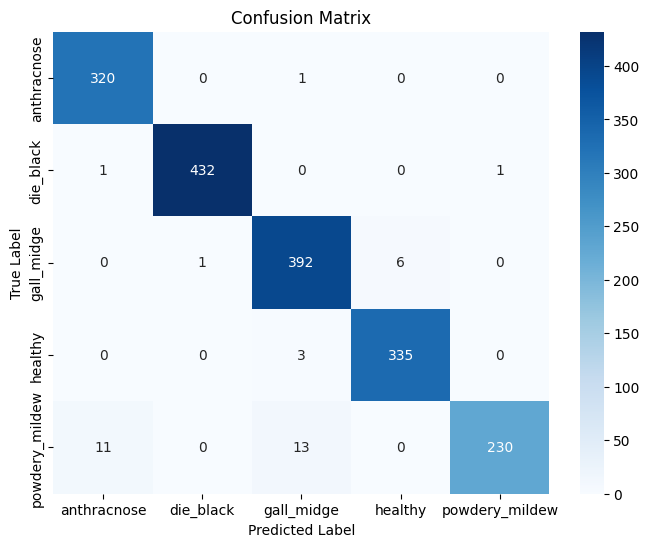

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Labels
class_labels = ['anthracnose', 'die_black', 'gall_midge', 'healthy', 'powdery_mildew']

# Predict class probabilities
y_pred_probs = model5.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Ensure y_test is in correct format
if len(y_test.shape) > 1 and y_test.shape[1] > 1:  # If one-hot encoded
    y_true = np.argmax(y_test, axis=1)  # Convert to class labels
else:  
    y_true = y_test  # Already in label format

# Compute accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Compute Sensitivity and Specificity for Multi-Class
class_sensitivity = np.diag(cm) / np.sum(cm, axis=1)  # Sensitivity per class
class_specificity = np.diag(cm) / np.sum(cm, axis=0)  # Specificity per class
sensitivity = np.mean(class_sensitivity)  # Mean Sensitivity
specificity = np.mean(class_specificity)  # Mean Specificity

# Print Evaluation Metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall (Sensitivity): {sensitivity:.4f}")
print(f"Test Specificity: {specificity:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [15]:
model5.save('/kaggle/working/DenseNet-201.keras')